## **Text Classification on SMS Dataset using tf-idf**

## **Aim of the Project**

* The aim of this project is to develop a machine learning-based system that can classify emails as **spam** or **ham**.

* The project focuses on text preprocessing, TF-IDF feature extraction, and machine learning models to accurately detect emails.

* The main goal is to improve email filtering performance and reduce **false positive errors**, ensuring that normal (ham) messages are correctly classified as ham.


In [129]:
# importing the libraries

from google.colab import files
import pandas as pd
import numpy as np
import string

import seaborn as sns
import matplotlib.pyplot as plt

# text pre-processing
import string
import nltk
from nltk.tokenize import word_tokenize ,sent_tokenize ,wordpunct_tokenize
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from wordcloud import WordCloud

nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')

# text embedding
from sklearn.feature_extraction.text import TfidfVectorizer

# model building
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB ,BernoulliNB ,GaussianNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier ,VotingClassifier
from xgboost import XGBClassifier

# evaluation metrics
from sklearn.metrics import precision_score ,confusion_matrix ,classification_report

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


In [ ]:
# load dataset

uploaded = files.upload()

for filename in uploaded.keys():
  print(uploaded[filename])

Saving spam (1).csv to spam (1) (1).csv
b'v1,v2,,,\r\nham,"Go until jurong point, crazy.. Available only in bugis n great world la e buffet... Cine there got amore wat...",,,\r\nham,Ok lar... Joking wif u oni...,,,\r\nspam,Free entry in 2 a wkly comp to win FA Cup final tkts 21st May 2005. Text FA to 87121 to receive entry question(std txt rate)T&C\'s apply 08452810075over18\'s,,,\r\nham,U dun say so early hor... U c already then say...,,,\r\nham,"Nah I don\'t think he goes to usf, he lives around here though",,,\r\nspam,"FreeMsg Hey there darling it\'s been 3 week\'s now and no word back! I\'d like some fun you up for it still? Tb ok! XxX std chgs to send, \xe5\xa31.50 to rcv",,,\r\nham,Even my brother is not like to speak with me. They treat me like aids patent.,,,\r\nham,As per your request \'Melle Melle (Oru Minnaminunginte Nurungu Vettam)\' has been set as your callertune for all Callers. Press *9 to copy your friends Callertune,,,\r\nspam,WINNER!! As a valued network customer you

In [ ]:
data = pd.read_csv('spam (1).csv', encoding='latin1')
data.head()

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN


## **Data Cleaning and Understanding**

In [ ]:
data.columns

Index(['v1', 'v2', 'Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4'], dtype='object')

In [ ]:
# dropping the columns

data = data.drop(['Unnamed: 2','Unnamed: 3','Unnamed: 4'] ,axis = 1)

In [ ]:
# rename the columns name

data = data.rename(columns={'v1':'target','v2':'text'})
data.head(2)

,target,text
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...


In [ ]:
# mapping the target column into 1 and 0

data['target'] = data['target'].map({'spam':1 ,'ham':0})

In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   target  5572 non-null   int64 
 1   text    5572 non-null   object
dtypes: int64(1), object(1)
memory usage: 87.2+ KB


In [ ]:
data.shape

(5572, 2)

In [ ]:
# check for null values

data.isnull().sum().sum()

np.int64(0)

In [ ]:
# check for duplicated

data.duplicated().sum()

np.int64(403)

In [ ]:
# dropping the duplicated records

data = data.drop_duplicates(keep='first')
data.head(2)

,target,text
0,0,"Go until jurong point, crazy.. Available only ..."
1,0,Ok lar... Joking wif u oni...


In [ ]:
data.duplicated().sum()

np.int64(0)

In [ ]:
# data augmentation --> we expanded the dataset using some function as we can see below

# len count for text characters
data['num_char'] = data['text'].apply(lambda x : len(x))

# also tokenizing text into word and sentence tokens to len for each text doucment
data['num_word'] = data['text'].apply(lambda x : len(word_tokenize(x)))
data['num_sent'] = data['text'].apply(lambda x : len(sent_tokenize(x)))


In [ ]:
data.head(5)

,target,text,num_char,num_word,num_sent
0,0,"Go until jurong point, crazy.. Available only ...",111,24,2
1,0,Ok lar... Joking wif u oni...,29,8,2
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37,2
3,0,U dun say so early hor... U c already then say...,49,13,1
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15,1


# **Exploratory Data Analysis**

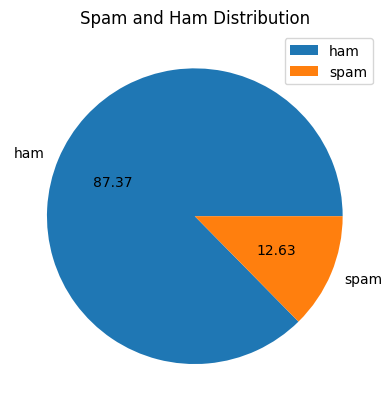

In [ ]:
# pie chart
# for non-spam vs spam

target = data['target'].value_counts()
plt.pie(x=target ,labels=['ham','spam'],autopct='%0.2f')
plt.title('Spam and Ham Distribution')
plt.legend()
plt.show()

**Observation** : the dataset have imbalance class such ham has 87.37% and spam has 12.63%

Here , **FalsePositive** is important metrics because we have to reduce the count of miss classifying text which are not spam as spam

In [ ]:
# histogram chart for ham and spam based on num_char ,num_word ,num_sent

# to get describe about the columns hue by target == ham
data[data['target']==0][['num_char','num_word', 'num_sent']].describe()

,num_char,num_word,num_sent
count,4516.000000,4516.000000,4516.000000
mean,70.459256,17.123782,1.820195
std,56.358207,13.493970,1.383657
min,2.000000,1.000000,1.000000
25%,34.000000,8.000000,1.000000
50%,52.000000,13.000000,1.000000
75%,90.000000,22.000000,2.000000
max,910.000000,220.000000,38.000000


In [ ]:
# to get describe about the columns hue by target == spam
data[data['target']==1][['num_char','num_word', 'num_sent']].describe()

,num_char,num_word,num_sent
count,653.000000,653.000000,653.000000
mean,137.891271,27.667688,2.970904
std,30.137753,7.008418,1.488425
min,13.000000,2.000000,1.000000
25%,132.000000,25.000000,2.000000
50%,149.000000,29.000000,3.000000
75%,157.000000,32.000000,4.000000
max,224.000000,46.000000,9.000000


**Observation** : Above is the mathematical description for given columns [num_char ,num_word ,num_sent]. This indicates **Spam text** do have more characters ,words ,sentences etc as compared to **Ham text** .

On an average spam text has **137** characters where else ham text has **70** characters

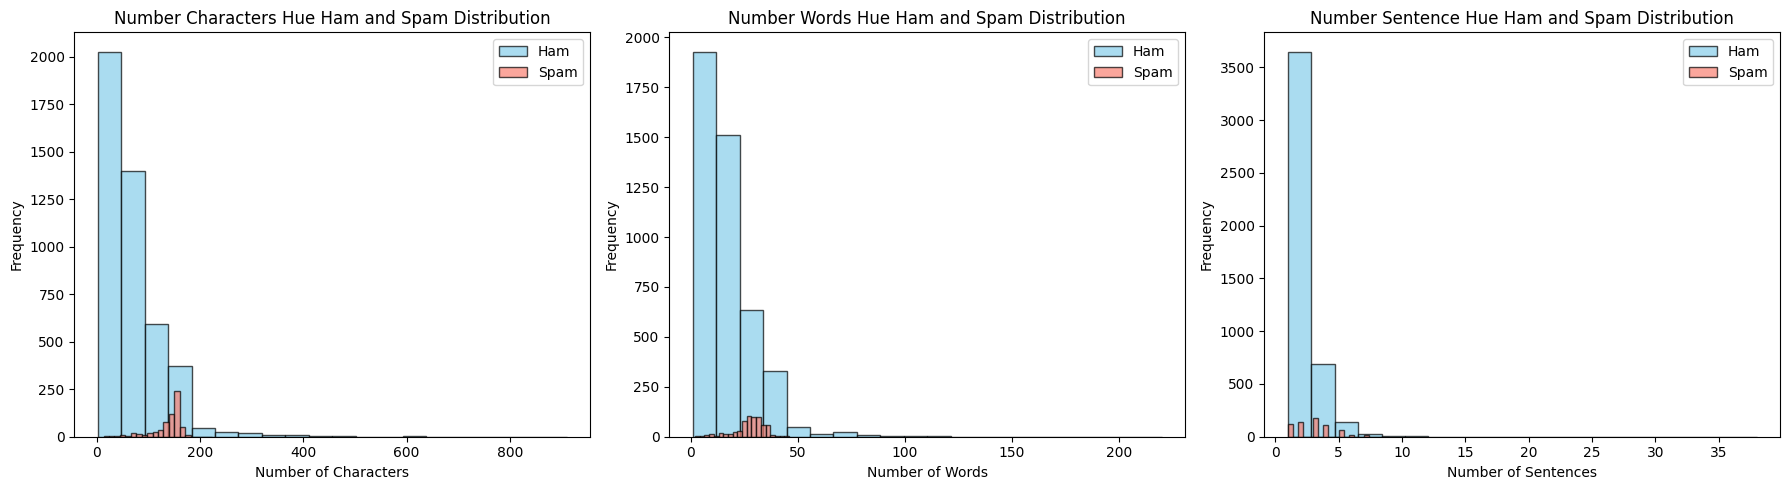

In [ ]:
# histogram for num_char, num_word, num_sent


fig, axs = plt.subplots(1, 3, figsize=(18, 5))

# Plot histograms for num_char, separated by target
axs[0].hist(data[data['target'] == 0]['num_char'], bins=20, color='skyblue', edgecolor='black', alpha=0.7, label='Ham')
axs[0].hist(data[data['target'] == 1]['num_char'], bins=20, color='salmon', edgecolor='black', alpha=0.7, label='Spam')
axs[0].set_title('Number Characters Hue Ham and Spam Distribution')
axs[0].set_xlabel('Number of Characters')
axs[0].set_ylabel('Frequency')
axs[0].legend()

# Plot histograms for num_word, separated by target
axs[1].hist(data[data['target'] == 0]['num_word'], bins=20, color='skyblue', edgecolor='black', alpha=0.7, label='Ham')
axs[1].hist(data[data['target'] == 1]['num_word'], bins=20, color='salmon', edgecolor='black', alpha=0.7, label='Spam')
axs[1].set_title('Number Words Hue Ham and Spam Distribution')
axs[1].set_xlabel('Number of Words')
axs[1].set_ylabel('Frequency')
axs[1].legend()

# Plot histograms for num_sent, separated by target
axs[2].hist(data[data['target'] == 0]['num_sent'], bins=20, color='skyblue', edgecolor='black', alpha=0.7, label='Ham')
axs[2].hist(data[data['target'] == 1]['num_sent'], bins=20, color='salmon', edgecolor='black', alpha=0.7, label='Spam')
axs[2].set_title('Number Sentence Hue Ham and Spam Distribution')
axs[2].set_xlabel('Number of Sentences')
axs[2].set_ylabel('Frequency')
axs[2].legend()


# Adjust layout to prevent overlapping labels
plt.tight_layout()
plt.show()

**Observation:** The dataset is imbalanced, with the number of non-spam (ham) messages being significantly higher than the number of spam messages. From this observation, we can analyze that the average number of characters, words, and sentences in the messages is approximately **137 characters, 27 words, and 3 sentences**, respectively.


## **Textual Data cleaning**

In [ ]:
# converting to lower case
# converting into word token
# spowords and punctuation removal
# reducing words to their root or base word --> lemmatization

In [ ]:
# to store the function variable
stopwords = stopwords.words('english')
punct = list(string.punctuation)
lemmatizer = WordNetLemmatizer()

# function for text tranformation
def transform_text(text):

  # converting into tokens
  tokens = word_tokenize(text.lower())

  # removal of stopwords and punctuation
  clean_tokens = [token for token in tokens if token not in stopwords and token not in punct]

  # lemmatization
  clean_tokens = [lemmatizer.lemmatize(tokens) for tokens in clean_tokens]

  return ' '.join(clean_tokens)


In [ ]:
# applying the function to the text column

data['transform_text'] = data['text'].apply(transform_text)

In [ ]:
data['transform_text']

,transform_text
0,go jurong point crazy .. available bugis n gre...
1,ok lar ... joking wif u oni ...
2,free entry 2 wkly comp win fa cup final tkts 2...
3,u dun say early hor ... u c already say ...
4,nah n't think go usf life around though
...,...
5567,2nd time tried 2 contact u. u å£750 pound priz...
5568,ì_ b going esplanade fr home
5569,pity mood ... suggestion
5570,guy bitching acted like 'd interested buying s...


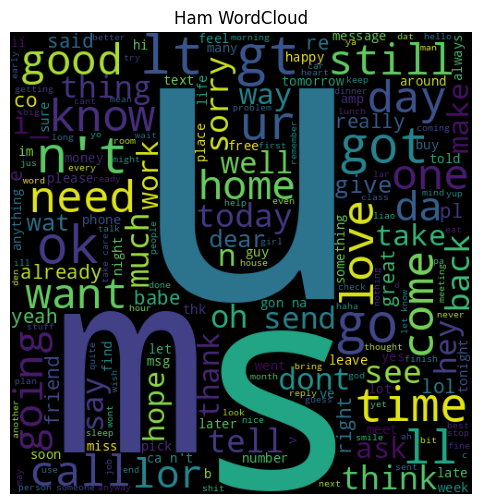

In [ ]:
# creating word cloud to analyze which words occur more in both the classes
# wordcloud for non-spam[ham]

ham_wc = WordCloud(width=500,height=500,min_font_size=10,background_color='black').generate(data[data['target']==0]['transform_text'].str.cat(sep=' '))

plt.figure(figsize =(10,6))
plt.imshow(ham_wc)
plt.title('Ham WordCloud')
plt.axis('off')
plt.show()

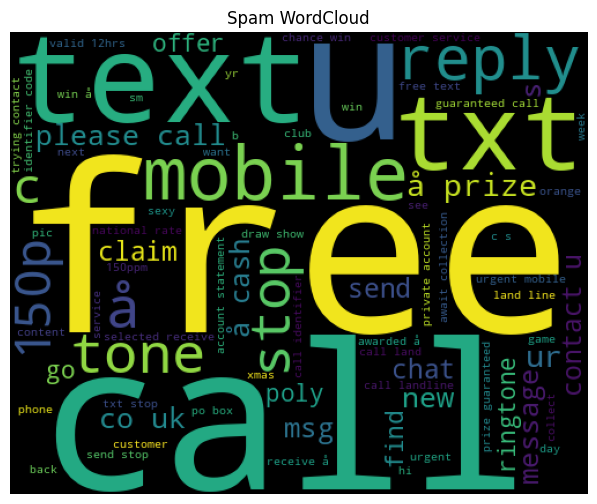

In [ ]:
# wordcloud for spam

spam_wc = WordCloud(width=500 ,height=400 ,min_font_size=10 ,background_color='black').generate(data[data['target']==1]['transform_text'].str.cat(sep=' '))
# str.cat(sep=' ') --> here we are taking the string and concating with space

plt.figure(figsize=(10,6))
plt.imshow(spam_wc)
plt.title('Spam WordCloud')
plt.axis('off')
plt.show()

**Observation :** From this analysis, we can identify the words that occur most frequently in both the **ham** and **spam** classes. This helps us understand which words are commonly used in each type of message.


# **Model Builiding**

In [ ]:
data.head(2)

,target,text,num_char,num_word,num_sent,transform_text
0,0,"Go until jurong point, crazy.. Available only ...",111,24,2,go jurong point crazy .. available bugis n gre...
1,0,Ok lar... Joking wif u oni...,29,8,2,ok lar ... joking wif u oni ...


In [ ]:
# for model building
# including only transform_text column for X

# text embedding for transform_text
# using tf-idf

tfidf = TfidfVectorizer(max_features=3000)
vectors = tfidf.fit_transform(data['transform_text']).toarray()

In [ ]:
# shape for X
vectors.shape

(5169, 3000)

In [ ]:
# splitting the data into X and Y

X = vectors
Y = data['target']

X_train ,X_test ,Y_train ,Y_test = train_test_split(X,Y,test_size=0.2,random_state=2)

In [ ]:
# shape for train set and test set

X_train.shape ,X_test.shape ,Y_train.shape ,Y_test.shape

((4135, 3000), (1034, 3000), (4135,), (1034,))

In [ ]:
# trying different models
# which model preform well

# this are the following models
# MultinomialNB()
# BernoulliNB()
# GaussianNB()
# LogisticRegression()
# RandomForestClassifier()
# XGBClassifier()

In [ ]:
# assigning variable to the models using voting classifier

model = VotingClassifier(
    estimators=[('MNaiveBayes', MultinomialNB(alpha=0.5)),
                ('BNaiveBayes', BernoulliNB(alpha=0.5 ,binarize=0.0)),
                ('LogReg', LogisticRegression(C=1.0 ,penalty='l2' ,solver='liblinear' ,random_state=42)),
                ('XGB', XGBClassifier(n_estimators=300 ,max_depth=5 ,learning_rate =0.5 ,subsample=0.8 ,
                                      colsample_bytree=0.8 ,min_child_weight=3 ,gamma=1 ,
                                      random_state=42))],
    voting='soft'
)


In [ ]:
# train the model

model.fit(X_train ,Y_train)

VotingClassifier(estimators=[('MNaiveBayes', MultinomialNB(alpha=0.5)),
                             ('BNaiveBayes', BernoulliNB(alpha=0.5)),
                             ('LogReg',
                              LogisticRegression(random_state=42,
                                                 solver='liblinear')),
                             ('XGB',
                              XGBClassifier(base_score=None, booster=None,
                                            callbacks=None,
                                            colsample_bylevel=None,
                                            colsample_bynode=None,
                                            colsample_bytree=0.8, device=None,
                                            early_stopping_rounds=None,
                                            enabl...
                                            feature_weights=None, gamma=1,
                                            grow_policy=None,
                                            importance_type=None,
                                            interaction_constraints=None,
                                            learning_rate=0.5, max_bin=None,
                                            max_cat_threshold=None,
                                            max_cat_to_onehot=None,
                                            max_delta_step=None, max_depth=5,
                                            max_leaves=None, min_child_weight=3,
                                            missing=nan,
                                            monotone_constraints=None,
                                            multi_strategy=None,
                                            n_estimators=300, n_jobs=None,
                                            num_parallel_tree=None, ...))],
                 voting='soft')

In [ ]:
# testing the model

y_predict = model.predict(X_test)

In [ ]:
print(classification_report(Y_test ,y_predict))

              precision    recall  f1-score   support

           0       0.99      1.00      0.99       896
           1       1.00      0.91      0.95       138

    accuracy                           0.99      1034
   macro avg       0.99      0.95      0.97      1034
weighted avg       0.99      0.99      0.99      1034



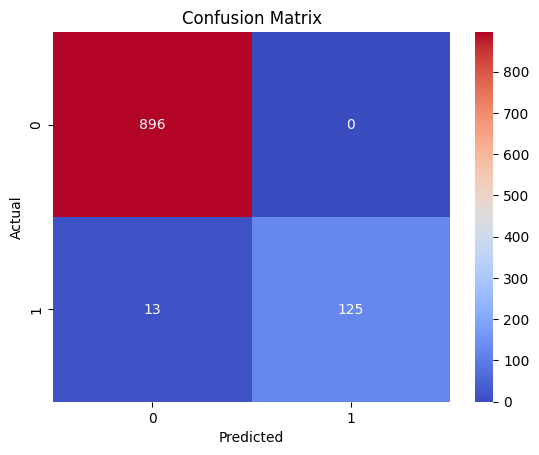

In [ ]:
# heatmap for confusion matrix

conf = confusion_matrix(Y_test ,y_predict)
sns.heatmap(conf ,annot=True ,fmt='d' ,cmap='coolwarm')
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

## **Model Building Summary :**

* In the model building phase, the **transform_text** column was converted into numerical vectors using **TF-IDF**. The dataset was then split into training and testing sets.


* After evaluating several machine learning models, the best performance was achieved with the following classifiers:
* MultinomialNB() ,BernoulliNB() ,LogisticRegression() and XGBClassifier()

* To further improve the overall model performance, we will combine these models using a Voting Classifier.This ensemble method combines the predictions of multiple models to produce a more accurate and reliable result.

* The final model achieved 99% precision and correctly classified almost all messages. Only 13 ham (non-spam) messages were incorrectly classified as spam, showing that the model has a very low false positive rate and performs well for spam detection.

## **Interactive session**

Here we have used Pickle is a Python module :
* In machine learning, it's commonly used to save trained models and preprocessing objects so you don't have to retrain them every time.

* Preserves the exact trained model and preprocessing objects.

* Makes it easy to deploy your model in applications such as web apps (e.g., Flask, Django, Streamlit) or desktop applications.

* Ensures that predictions use the same preprocessing (such as the same TF-IDF vocabulary) that was used during training.

In [ ]:
import pickle

pickle.dump(tfidf, open("tfidf.pkl","wb"))
pickle.dump(model, open("model.pkl","wb"))

In [ ]:
tfidf = pickle.load(open("tfidf.pkl","rb"))
model = pickle.load(open("model.pkl","rb"))

In [ ]:
# interactive session where model will predict whether the message are ham or spam

# import the libraries
import string
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

stop_words = set(stopwords.words('english'))
punct = set(string.punctuation)
lemmatizer = WordNetLemmatizer()

# function for text transformation
def transform_text_for_prediction(text):

  tokens = word_tokenize(text.lower())
  clean_tokens = [token for token in tokens if token not in stop_words and token not in punct]
  lemma_tokens = [lemmatizer.lemmatize(token) for token in clean_tokens]

  return ' '.join(lemma_tokens)


# function for user input ,text embedding and prediction
def predict_message():
    email = input("Enter the email text: ")

    cleaned_text = transform_text_for_prediction(email)

    vectors = tfidf.transform([cleaned_text])

    prediction = model.predict(vectors)[0]

    if prediction == 1:
        print("The message is Spam")
    else:
        print("The message is Ham")

In [ ]:
predict_message()

Enter the email text: hello can we meet today !
Ham


In [ ]:
predict_message()

Enter the email text: You have won a free iPhone! Claim your prize now by clicking this link.
Spam


In [ ]:
predict_message()

Enter the email text: Don't forget to bring the documents for tomorrow's meeting.
Ham


In [ ]:
predict_message()

Enter the email text: Your order has been delivered. Thank you for shopping with us.
Ham


In [ ]:
predict_message()

Enter the email text: You have been chosen for an exclusive reward. Click here to confirm your eligibility and claim your gift.
Spam


In [ ]:
predict_message()

Enter the email text: Please review the report and share your feedback before tomorrow.
Ham


## **Interactive Session**

* This session was created to test the trained spam and ham email classification model with new user inputs.

* The user can enter an email message, and the system processes the text, converts it into TF-IDF features, and predicts whether the message is **spam** or **ham**.

* The model was able to provide predictions on new messages, making the spam detection system more practical and user-friendly.
